In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix,  roc_curve, roc_auc_score,precision_score,precision_recall_curve, recall_score, f1_score, average_precision_score

In [2]:
df = pd.read_csv(r'online_shoppers_intention_preprocessed.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12205 entries, 0 to 12204
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  int64  
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType           

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.00,0.20,0.20,0.0,0.0,2,1,1,1,1,1,0,0
1,0,0.0,0,0.0,2,64.00,0.00,0.10,0.0,0.0,2,2,2,1,2,1,0,0
2,0,0.0,0,0.0,1,0.00,0.20,0.20,0.0,0.0,2,4,1,9,3,1,0,0
3,0,0.0,0,0.0,2,2.67,0.05,0.14,0.0,0.0,2,3,2,2,4,1,0,0
4,0,0.0,0,0.0,10,627.50,0.02,0.05,0.0,0.0,2,3,3,1,4,1,1,0


In [3]:
df.keys()

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

In [4]:
X = df.drop('Revenue', axis=1)
y = df['Revenue']

In [5]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.00,0.20,0.20,0.0,0.0,2,1,1,1,1,1,0,0
1,0,0.0,0,0.0,2,64.00,0.00,0.10,0.0,0.0,2,2,2,1,2,1,0,0
2,0,0.0,0,0.0,1,0.00,0.20,0.20,0.0,0.0,2,4,1,9,3,1,0,0
3,0,0.0,0,0.0,2,2.67,0.05,0.14,0.0,0.0,2,3,2,2,4,1,0,0
4,0,0.0,0,0.0,10,627.50,0.02,0.05,0.0,0.0,2,3,3,1,4,1,1,0


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

In [9]:
mlp.fit(X_train_scaled, y_train)
y_pred = mlp.predict(X_test_scaled)
y_probs = mlp.predict_proba(X_test_scaled)[:, 1]

In [10]:
# Precision: Of all the sessions the model predicted would result in revenue, 
#            how many actually ended in a purchase? 
# Recall: Of all the sessions that actually resulted in revenue, 
#         how many did the model successfully identify? 
# F1-Score: The harmonic mean of precision and recall, providing a single score 
#           that balances both concerns.

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8701351904956984

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.93      0.92      2079
           1       0.56      0.55      0.56       362

    accuracy                           0.87      2441
   macro avg       0.74      0.74      0.74      2441
weighted avg       0.87      0.87      0.87      2441


Confusion Matrix:
 [[1925  154]
 [ 163  199]]


Text(45.72222222222221, 0.5, 'Actual')

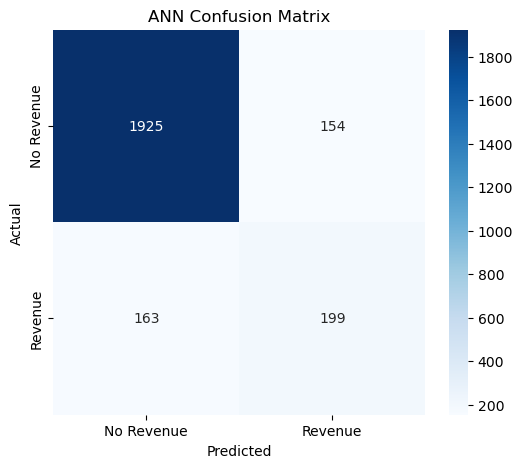

In [12]:
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Revenue', 'Revenue'], yticklabels=['No Revenue', 'Revenue'])
plt.title('ANN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [13]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

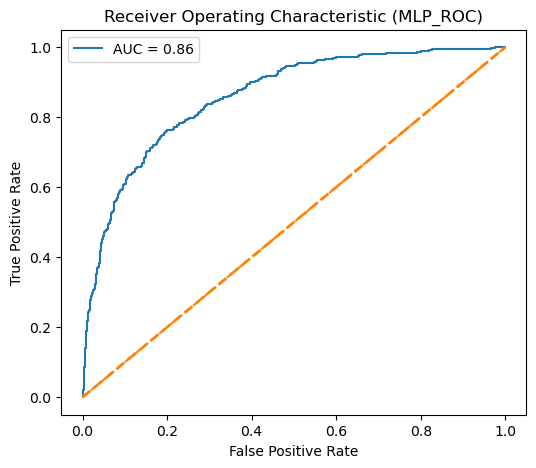

In [14]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], color='darkorange', lw=2, linestyle='--')
plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (MLP_ROC)')
plt.legend()

plt.show()

In [15]:
precision, recall, _ = precision_recall_curve(y_test, y_probs)
ap_score = average_precision_score(y_test, y_probs)

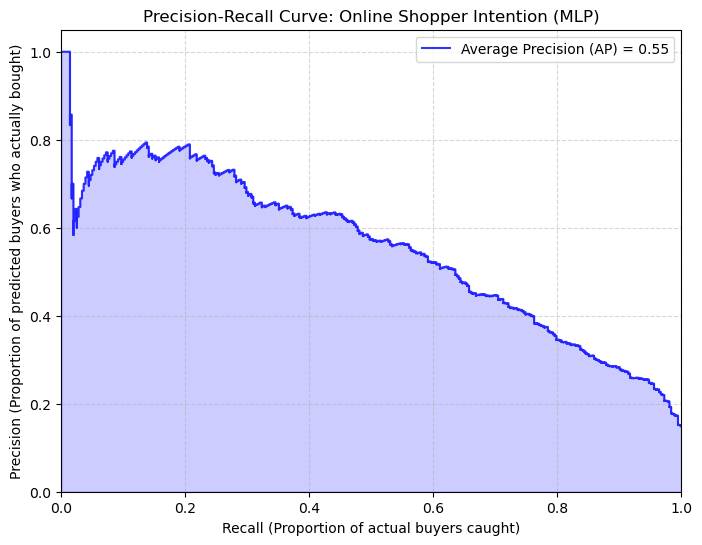

Average Precision (AP): 0.5522


In [16]:
plt.figure(figsize=(8, 6))
plt.step(recall, precision, color='b', alpha=0.8, where='post', label=f'Average Precision (AP) = {ap_score:.2f}')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='b')

plt.xlabel('Recall (Proportion of actual buyers caught)')
plt.ylabel('Precision (Proportion of predicted buyers who actually bought)')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curve: Online Shopper Intention (MLP)')
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Average Precision (AP): {ap_score:.4f}")